In [60]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub
/home/yuanshanwu/Documents


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [61]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'nifti', 'avi']


In [62]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [63]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [64]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['load_bolus_mask', 'nifti']


In [65]:
seg_type = 'nifti'

seg_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/Test_VOI.nii.gz'
seg_loader_kwargs = {}

In [69]:
from src.entrypoints import seg_loading_step

# Testing the motion compensation, right now is hard coded
seg_data = seg_loading_step(seg_type, image_data, seg_path, CEUS_scan_path, **seg_loader_kwargs)

## Segmentation Preprocessing

In [13]:
from src.seg_preprocessing.options import get_seg_preproc_funcs, get_required_seg_preproc_kwargs

print("Available preprocessing functions:", list(get_seg_preproc_funcs().keys()))

Available preprocessing functions: ['resample', 'motion_compensation_3d']


In [14]:
preproc_func_names = ['motion_compensation_3d'] # in order of application
required_kwargs = get_required_seg_preproc_kwargs(preproc_func_names)
print("Required kwargs for preprocessing functions:", required_kwargs)

Required kwargs for preprocessing functions: ['bmode_image_data', 'padding', 'search_margin_ratio']


In [15]:
preproc_kwargs = {
    # For apply motion compensation function
    # 'motion_json_path':'/Users/wuyuanshan/Desktop/Github/CEUS_3D_MotionCompensation/motion_tracking_TJU-P02-V01-CEUS 2_10.43.42.json'

    # for motionc_compensation_3d
    'bmode_image_data': bmode_image_data,
    'padding': 3,
    'search_margin_ratio':0.03
}

In [13]:
bmode_image_data.pixel_data.shape
# Where the dimension is Lateral, Depth, Elevation, Time

(195, 144, 145, 530)

In [14]:
from src.entrypoints import seg_preprocessing_step

seg_data = seg_preprocessing_step(preproc_func_names, image_data, seg_data, **preproc_kwargs)


3D Motion Compensation with ILSA Tracking (Memory Efficient)

Step 1: Extracting bounding box from segmentation...
  Bounding box: Z=[33, 105], Y=[55, 104], X=[82, 140]
  Center: (np.float64(111.0), np.float64(79.5), np.float64(69.0))

Step 2: Tracking motion using forward and backward correlation...
  Reference frame: 0
  Search margin ratio: 0.03

=== Reference-Only Tracking Mode ===
All frames will be tracked from reference frame only


Tracking frames: 100%|██████████| 529/529 [00:46<00:00, 11.27frame/s]
Tracking frames (backward): 0frame [00:00, ?frame/s]


=== Tracking Complete ===
Sources: {'reference': 1, 'reference_only': 529}
Mean correlation: 0.442
Min correlation: 0.329

Step 3: Computing translation vectors...
  Frame 0: shift=(0.0, 0.0, 0.0), corr=1.000
  Frame 10: shift=(-7.0, -1.0, -4.0), corr=0.499
  Frame 20: shift=(-10.0, -1.0, -7.0), corr=0.450
  Frame 30: shift=(-11.0, -1.0, -6.0), corr=0.447
  Frame 40: shift=(-11.0, -1.0, -6.0), corr=0.447
  Frame 50: shift=(-11.0, -1.0, -5.0), corr=0.448
  Frame 60: shift=(-10.0, 0.0, -4.0), corr=0.456
  Frame 70: shift=(-12.0, -1.0, -6.0), corr=0.446
  Frame 80: shift=(-13.0, -1.0, -7.0), corr=0.432
  Frame 90: shift=(-14.0, -1.0, -6.0), corr=0.425
  Frame 100: shift=(-17.0, -1.0, -7.0), corr=0.393
  Frame 110: shift=(-13.0, -1.0, -2.0), corr=0.438
  Frame 120: shift=(-8.0, 0.0, 0.0), corr=0.570
  Frame 130: shift=(-5.0, 1.0, 0.0), corr=0.553
  Frame 140: shift=(-10.0, 0.0, -4.0), corr=0.421
  Frame 150: shift=(-14.0, 0.0, -6.0), corr=0.429
  Frame 160: shift=(-6.0, 0.0, -1.0), corr=0

In [18]:
seg_data.motion_compensation.__dict__

{'translation_vectors': array([[  0.,   0.,   0.],
        [  2.,   1.,   1.],
        [  1.,   1.,   0.],
        ...,
        [-17.,  -1.,  -3.],
        [-14.,  -1.,   0.],
        [ -9.,   0.,   1.]], shape=(530, 3), dtype=float32),
 'reference_frame': 0,
 'correlations': array([1.        , 0.6107847 , 0.56868905, 0.48230478, 0.47737274,
        0.46125275, 0.4515371 , 0.4435168 , 0.4406855 , 0.44517416,
        0.49859732, 0.5875971 , 0.38275114, 0.5275497 , 0.5887614 ,
        0.475842  , 0.48072976, 0.45452675, 0.45837677, 0.43154263,
        0.45041585, 0.4337742 , 0.47970086, 0.5789899 , 0.32867336,
        0.38841516, 0.46078342, 0.44342995, 0.48032117, 0.44446018,
        0.44685805, 0.42069027, 0.4358512 , 0.4379684 , 0.49392754,
        0.5254736 , 0.47877485, 0.5261971 , 0.51005936, 0.44093996,
        0.44738868, 0.42573497, 0.43036327, 0.4248757 , 0.47265407,
        0.55033827, 0.369616  , 0.46310398, 0.5520872 , 0.43816668,
        0.44761282, 0.4398709 , 0.44348988, 

## Visualizing Motion Compensated Results


In [70]:
# Use inline backend - MORE RELIABLE for Jupyter
%matplotlib inline

import cv2
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import io
from tqdm import tqdm

def enhance_bmode_noise(image_slice, p_low_percentile=2.0, p_high_percentile=98.0):
    non_zero = image_slice[image_slice != 0]
    # Compute 10th and 90th percentile on non-zero values
    p_low = np.percentile(non_zero, 2)
    p_high = np.percentile(non_zero, 98)

    # Clip and normalize to 0-255
    clipped_slice = np.clip(image_slice, p_low, p_high)
    normalized_slice = ((clipped_slice - p_low) / (p_high - p_low) * 255).astype(np.uint8)
    
    return normalized_slice


def get_mask_boundary(mask_slice):
    """Extract boundary of a binary mask using erosion."""
    if mask_slice.max() == 0:
        return np.zeros_like(mask_slice, dtype=bool)
    eroded = binary_erosion(mask_slice)
    boundary = mask_slice.astype(bool) & ~eroded
    return boundary

def get_voi_center(mask_3d):
    """Calculate the center of a 3D VOI mask."""
    coords = np.where(mask_3d > 0)
    if len(coords[0]) == 0:
        return None, None, None
    lateral_center = int(np.mean(coords[0]))
    depth_center = int(np.mean(coords[1]))
    elevation_center = int(np.mean(coords[2]))
    return lateral_center, depth_center, elevation_center

print(f"Image shape: {image_data.pixel_data.shape}")
# print(f"Mask shape: {seg_data.seg_mask.shape}")

# Define slice positions
lateral_slice = int(image_data.pixel_data.shape[0]/2)
depth_slice = int(image_data.pixel_data.shape[1]/2)
elevation_slice = int(image_data.pixel_data.shape[2]/2)

# Frame range
num_frames = image_data.pixel_data.shape[3]
start_frame = 0
end_frame =  272# num_frames  # Visualize all frames

print(f"Visualizing frames {start_frame} to {end_frame}")
print("Starting animation...\n")

MC_flag = False  # Set to True to visualize motion compensated mask
# List to store frames
frames = []

# Loop through frames
for frame in tqdm(range(start_frame, end_frame), desc="Creating mp4 frames"):
    # Clear previous output and display current frame
    clear_output(wait=True)

    if MC_flag:
        wo_mc_mask = seg_data.seg_mask
        mask = seg_data.motion_compensation.apply_to_mask(wo_mc_mask, frame, 0)
    else:
        mask = seg_data.seg_mask
        
    # Calculate VOI center for this specific frame
    lateral_slice, depth_slice, elevation_slice = get_voi_center(mask)
    
    if lateral_slice is None:
        print(f"Warning: No VOI found in frame {frame}, skipping...")
        continue
    
    # Create figure for this frame
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # === AXIAL VIEW ===
    Volume_data = bmode_image_data.pixel_data[:, :, :, frame]
    # Need a better visualization

    axial_img = np.transpose(Volume_data[:, :, elevation_slice])
    axial_mask = np.transpose(mask[:, :, elevation_slice])
    wo_axial_mask = np.transpose(wo_mc_mask[:, :, elevation_slice])
    
    axial_boundary = get_mask_boundary(axial_mask)
    wo_axial_boundary = get_mask_boundary(wo_axial_mask)

    axes[0].imshow(enhance_bmode_noise(axial_img), cmap='gray')
    axes[0].contour(axial_boundary, colors='red', linewidths=2)
    axes[0].contour(wo_axial_boundary, colors='blue', linewidths=2, linestyles='dashed')
    axes[0].set_title(f'Axial (Z={elevation_slice})')
    axes[0].set_xlabel('Lateral (X)')
    axes[0].set_ylabel('Depth (Y)')
    
    # === CORONAL VIEW ===
    coronal_img = Volume_data[:, depth_slice, :]
    coronal_mask = mask[:, depth_slice, :]
    coronal_boundary = get_mask_boundary(coronal_mask)
    
    axes[1].imshow(enhance_bmode_noise(coronal_img), cmap='gray')
    axes[1].contour(coronal_boundary, colors='red', linewidths=2)
    axes[1].set_title(f'Coronal (Y={depth_slice})')
    axes[1].set_xlabel('Elevation (Z)')
    axes[1].set_ylabel('Lateral (X)')
    
    # === SAGITTAL VIEW ===
    sagittal_img = Volume_data[lateral_slice, :, :]
    sagittal_mask = mask[lateral_slice, :, :]
    sagittal_boundary = get_mask_boundary(sagittal_mask)
    
    axes[2].imshow(enhance_bmode_noise(sagittal_img), cmap='gray')
    axes[2].contour(sagittal_boundary, colors='red', linewidths=2)
    axes[2].set_title(f'Sagittal (X={lateral_slice})')
    axes[2].set_xlabel('Elevation (Z)')
    axes[2].set_ylabel('Depth (Y)')
    
    # Add overall frame counter
    fig.suptitle(f'Frame {frame}/{end_frame-1}', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Convert figure to image array (COMPATIBLE METHOD)
    # buf = io.BytesIO()
    # fig.savefig(buf, format='png', dpi=100)
    # buf.seek(0)
    # img = Image.open(buf).convert('RGB')
    # frames.append(np.array(img))
    # buf.close()
    
    # Print progress
    print(f"Frame {frame}/{end_frame-1}")
    
    # Close figure to save memory
    plt.close(fig)

# Writing into a video
# Get dimensions from first frame
# height, width = frames[0].shape[:2]

# # Save as MP4
# output_filename = '/media/yuanshanwu/Extreme Pro/Yuanshan/RawData/TJU-P06/TJU-P06-V01/CEUS_video.mp4'
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or use 'avc1' for H.264
# out = cv2.VideoWriter(output_filename, fourcc, 15.0, (width, height))

# # Write frames
# for frame in frames:
#     # Convert RGB to BGR for OpenCV
#     frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
#     out.write(frame_bgr)

# # # Release video writer
# out.release()

# print(f"\nMP4 saved as: {output_filename}")
print(f"Total frames: {len(frames)}")

Creating mp4 frames:   3%|▎         | 8/272 [00:02<01:25,  3.07it/s]


KeyboardInterrupt: 

In [16]:
# Save the segmentation data with motion compensation applied
import pickle
from pathlib import Path

# Build output path: split CEUS_scan_path at 'HighQuality' and append pkl filename
base_path = CEUS_scan_path.split('HighQuality')[0]
output_pkl_path = str(Path(base_path) / 'HighQuality' / 'seg_data_with_mc_correlation_based.pkl')
print(f"Saving to: {output_pkl_path}")
# Save seg_data with motion compensation
with open(output_pkl_path, 'wb') as f:
    pickle.dump(seg_data, f)

Saving to: /home/yuanshanwu/Documents/TUL/CEUS-Studies/P07-V02-CE01/HighQuality/seg_data_with_mc_correlation_based.pkl


## Correct the NIFTI data back to motion compensated data

In [ ]:
from scipy.ndimage import shift
import numpy as np
from tqdm import tqdm
import os
import pickle

# Get data
translation_vectors = seg_data.motion_compensation.translation_vectors
ceus_data = bmode_image_data.pixel_data

# Output directory for pkl files
output_dir = str(Path(base_path) / 'HighQuality' / 'bmode_frames_pkl')
os.makedirs(output_dir, exist_ok=True)

n_frames = ceus_data.shape[-1]
dtype = ceus_data.dtype

print("Processing and saving frames as .pkl files...")

for frame_idx in tqdm(range(n_frames), desc="Motion compensation"):
    dx, dy, dz = translation_vectors[frame_idx]
    
    # Load frame
    frame = ceus_data[..., frame_idx]
    
    # Apply motion compensation
    mc_frame = shift(frame, shift=[-dx, -dy, -dz], order=0, cval=0)
    
    # Save as pickle file
    pkl_path = os.path.join(output_dir, f'mc_frame_{frame_idx:04d}.pkl')
    with open(pkl_path, 'wb') as f:
        pickle.dump(mc_frame, f)
    
    # Clear memory
    del frame, mc_frame

print(f"Done! Saved {n_frames} frames to {output_dir}")
print(f"Each file named as: mc_frame_0000.pkl, mc_frame_0001.pkl, ...")

In [ ]:
import pickle
import nibabel as nib
import numpy as np
from tqdm import tqdm
import os
from pathlib import Path

# Directory with pkl files
pkl_dir = Path('/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/MotionCompensated/bmode_frames_pkl')
output_nii = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/MotionCompensated/mc_bmode_image_4d.nii'

# Get all pkl files
pkl_files = sorted([f for f in pkl_dir.iterdir() if f.name.endswith('.pkl')],
                   key=lambda x: int(x.stem.split('_')[-1]))  # Sort by frame number
n_frames = len(pkl_files)

print(f"Found {n_frames} .pkl files")

# Load first frame to get shape and dtype
with open(pkl_files[0], 'rb') as f:
    first_frame = pickle.load(f)
    frame_shape = first_frame.shape
    dtype = first_frame.dtype

print(f"Frame shape: {frame_shape}")
print(f"Data type: {dtype}")

output_shape = frame_shape + (n_frames,)
print(f"Output shape: {output_shape}")

# Create affine matrix (identity - adjust if you have resolution info)
affine = np.eye(4)

# Create NIfTI header
header = nib.Nifti1Header()
header.set_data_shape(output_shape)
header.set_data_dtype(dtype)
header.set_data_offset(352)  # Standard NIfTI1 header size

# Write header first
print("Writing NIfTI header...")
with open(output_nii, 'wb') as f:
    f.write(header.binaryblock)
    # Pad to data offset
    current_pos = f.tell()
    padding_needed = 352 - current_pos
    if padding_needed > 0:
        f.write(b'\x00' * padding_needed)

print("Merging frames...")

# Append frame data one at a time
with open(output_nii, 'ab') as f:
    for pkl_file in tqdm(pkl_files, desc="Writing frames"):
        # Load pkl
        with open(pkl_file, 'rb') as pf:
            mc_frame = pickle.load(pf)

        f.write(mc_frame.tobytes(order='F'))
        
        del mc_frame

print(f"✓ Done! Saved to {output_nii}")
print(f"File size: {Path(output_nii).stat().st_size / (1024**3):.2f} GB")

# Verify by loading
print("\nVerifying file...")
img = nib.load(output_nii)
print(f"Loaded shape: {img.shape}")
print(f"Loaded dtype: {img.get_data_dtype()}")
print("✓ File is readable!")

## CEUS Quantitative Temporal Curve Analysis

In [48]:
from src.time_series_analysis.options import get_analysis_types, get_required_kwargs

all_analysis_types, all_analysis_funcs = get_analysis_types()
print("Available analysis types:", list(all_analysis_types.keys()))

Available analysis types: ['curves', 'curves_paramap']


In [49]:
analysis_type = 'curves'

print("Available analysis functions:", list(all_analysis_funcs.keys()))

Available analysis functions: ['tic', 'pyradiomics']


In [50]:
analysis_funcs = ['tic']

# Find all required kwargs for the analysis functions
analysis_funcs = analysis_funcs if len(analysis_funcs) else list(all_analysis_funcs[analysis_type].keys())
required_kwargs = get_required_kwargs(analysis_type, analysis_funcs)
print("Required kwargs for current analysis:", required_kwargs)

Required kwargs for current analysis: []


In [51]:
analysis_kwargs = {
    # 'pyradiomics_config_paths': [
    #     '/home/das/QuantUS_Projs/QuantUS-Plugins-CEUS/configs/pyradiomics/moderate-pselectin.yml',
    # ],
    # 'curves_output_path': 'test2.csv',
    # 'binwidth': 25,
    # 'min_intensity': 0,
}

In [52]:
print(image_data.intensities_for_analysis.shape)
seg_data.use_mc = True
print(seg_data.use_mc)

(295, 218, 219, 530)
True


In [54]:
from src.entrypoints import analysis_step

analysis_obj = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

Computing curves: 100%|██████████| 530/530 [00:56<00:00,  9.44it/s]


In [58]:
seg_data.use_mc = False
print(seg_data.use_mc)

False


In [59]:
from src.entrypoints import analysis_step

analysis_obj_wo_mc = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

Computing curves: 100%|██████████| 530/530 [00:05<00:00, 94.34it/s]


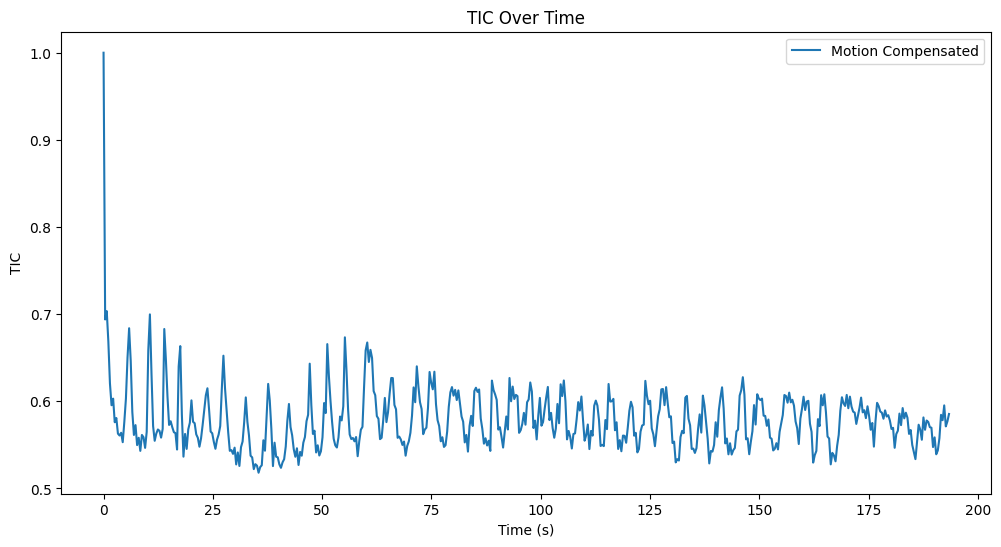

In [56]:
import matplotlib.pyplot as plt
import numpy as np
# Create a figure with a specific size (e.g., 8 inches wide, 6 inches tall)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(analysis_obj.time_arr,seg_data.motion_compensation.correlations, label='Motion Compensated')

ax.set_xlabel('Time (s)')
ax.set_ylabel('TIC')
ax.set_title('TIC Over Time')
ax.legend()

NameError: name 'analysis_obj_wo_mc' is not defined

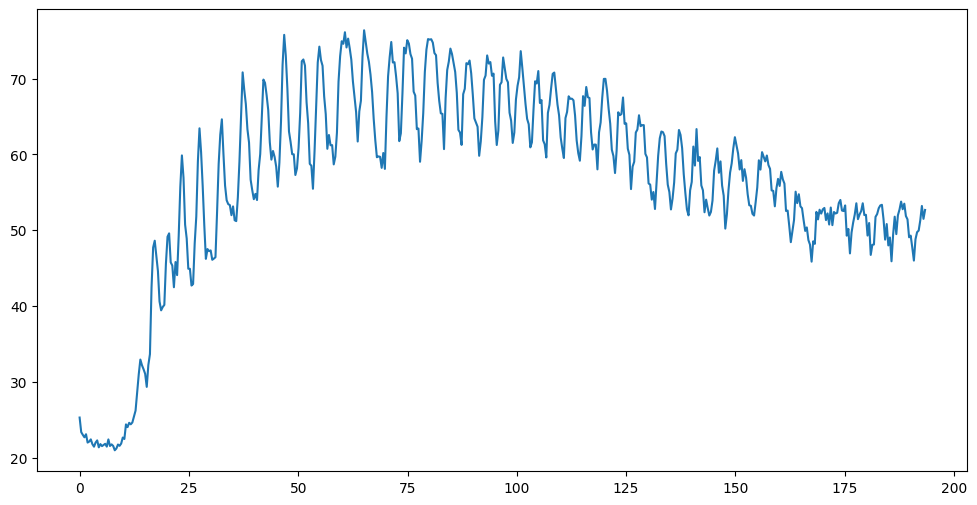

In [57]:
import matplotlib.pyplot as plt

# Create a figure with a specific size (e.g., 8 inches wide, 6 inches tall)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(analysis_obj.time_arr,analysis_obj.curves[0]['TIC'], label='Motion Compensated')
ax.plot(analysis_obj_wo_mc.time_arr,analysis_obj_wo_mc.curves[0]['TIC'], label='Without Motion Compensation')

ax.set_xlabel('Time (s)')
ax.set_ylabel('TIC')
ax.set_title('TIC Over Time')
ax.legend()

plt.show()

In [2]:
import pickle
with open('/home/yuanshanwu/Documents/TUL/CEUS-Studies/P07-V02-CE01/HighQuality/seg_data_with_mc_correlation_based.pkl', 'rb') as f:
    seg_data = pickle.load(f)

ModuleNotFoundError: No module named 'src'

# Curve Quantification

In [29]:
from src.curve_quantification.options import get_quantification_funcs

quantification_funcs = get_quantification_funcs()
print("Available quantification functions:", quantification_funcs.keys())

Available quantification functions: dict_keys(['lognormal_fit_full', 'dte', 'wash_rates', 'first_order_select', 'first_order_full', 'cmus_firstorder', 'auc_no_fit', 'lognormal_fit_select'])


In [30]:
function_names = ['lognormal_fit_full'] # Empty list will use all functions
output_path = 'test_quants.csv'
curve_quantifications_kwargs = {
    'curves_to_fit': ['TIC'],
}
print("Required kwargs for preprocessing functions:", required_kwargs)

Required kwargs for preprocessing functions: []


In [31]:
from src.entrypoints import curve_quantification_step

curve_quant = curve_quantification_step(analysis_obj, function_names, output_path, **curve_quantifications_kwargs)

In [39]:
output_path_wo_mc = 'test_quants_wo_mc.csv'
curve_quant = curve_quantification_step(analysis_obj_wo_mc, function_names, output_path_wo_mc, **curve_quantifications_kwargs)

## Evaluation of the Motion compensation

In [ ]:
from src.mc_evaluation_metrics import *
# ============================================================================
# ============================================================================
# PART 1: VOI B-mode Similarity Analysis (CORRECTED)
# ============================================================================

print("\n" + "="*70)
print("PART 1: B-MODE SIMILARITY WITHIN VOI")
print("="*70)

# Compute B-mode similarity within VOI
voi_results = compute_voi_bmode_similarity_comparison(
    bmode_image_data.pixel_data[:,:,:,:380],
    seg_data.seg_mask,
    seg_data.motion_compensation,
    reference_frame=0,
)

In [ ]:
# Plot comparison
plot_voi_bmode_similarity_comparison(
    voi_results,
    output_path='voi_bmode_similarity_comparison.png'
)

# Print summary
print("\nB-mode Similarity Summary (Within VOI):")
print("-" * 70)
print("This measures if VOI is tracking the SAME TISSUE")
print("(based on B-mode intensity appearance)\n")

for metric in ['correlation', 'ssim']:
    mean_mc = np.mean(voi_results['with_mc'][metric])
    std_mc = np.std(voi_results['with_mc'][metric])
    mean_no_mc = np.mean(voi_results['without_mc'][metric])
    std_no_mc = np.std(voi_results['without_mc'][metric])
    improvement = ((mean_mc - mean_no_mc) / (mean_no_mc + 1e-10)) * 100
    
    print(f"{metric.upper():15s}: MC={mean_mc:.3f}±{std_mc:.3f}, "
          f"No-MC={mean_no_mc:.3f}±{std_no_mc:.3f}, Improvement={improvement:+.1f}%")

# Error metrics (lower is better)
print("\nError Metrics (Lower is Better):")
print("-" * 70)
for metric in ['mse', 'mae']:
    mean_mc = np.mean(voi_results['with_mc'][metric])
    mean_no_mc = np.mean(voi_results['without_mc'][metric])
    reduction = ((mean_no_mc - mean_mc) / (mean_no_mc + 1e-10)) * 100
    
    print(f"{metric.upper():15s}: MC={mean_mc:.1f}, No-MC={mean_no_mc:.1f}, "
          f"Reduction={reduction:.1f}%")

In [ ]:
plot_voi_bmode_similarity_comparison(
    voi_results,
    output_path='voi_bmode_similarity_comparison.png'
)